# Classification results deep dive

Four analyses requested on top of the aggregate comparisons already in
`compare_classifier_results.ipynb`, all driven purely by `results_summary.yaml` /
`split_informations.yaml` / `grid_search_results.csv` under `RESULTS_ROOT` -- no
embeddings, WSIs, or RNA data needed (see `saved_cells_deep_dive.ipynb` for the
per-cell analyses that do need those, on `test_predictions.csv`).

1. **UNI2 context-size sweep** -- performance of the `nucleus` read-out at
   increasing native field-of-view (`UNI2_448_resized` / `UNI2_896_resized` /
   `UNI2_1344_resized`, plus `UNI2_448_224_multicell`'s different extraction path
   at the same nominal size): which splits and cell types lose the most as
   context grows.
2. **CLS vs. central** for `{UNI2, UNI2_100_resized, UNI2_448_resized,
   HOptimus1, virchow_v2}`: per-split and per-class-F1 comparison of each
   model's CLS read-out against its "central" (spatially-indexed) read-out.
3. **Cell-type availability vs. performance**: does a class's per-class F1
   track how many training cells of that class were available, for
   `{HOptimus1, UNI2, virchow_v2}` central tokens.
4. **Scaling law**: model parameter count and embedding dimension vs. mean
   macro-F1, same three models, central tokens.

## "Central" read-out, by model

There are two distinct non-CLS spatially-indexed read-outs on disk (see the
top-level README's "Read-out notation" table): the four-corner mean pool
(`bottom_left_bottom_right_top_left_top_right`, what
`classifier_results_analysis.ipynb` in `Bulk_Deconvolution_HNE_Prior` calls
"central pooling") and the newer boundary-polygon-pooled `nucleus` token.
`CENTRAL_EMBEDDING_TYPE` below picks whichever one each model actually has on
disk -- **this is a guess encoded from what's currently available**, not a
verified convention; update the dict if a model gets a second read-out
extracted and you want to switch which one counts as "central" for it.

## Reusing this notebook

Everything is driven by `MODEL_INFO` / `CENTRAL_EMBEDDING_TYPE` /
`discover_results()` below -- to add a newly-synced model folder, add one row
to the relevant dict (or nothing, for the auto-discovering parts) and rerun.
Sections `## A`-`## D` are independent; skip the ones you don't need. Two
generic plotting helpers (`plot_metric_vs_condition_by_split`,
`plot_per_class_heatmap`) are reused by both `A` and `B` -- add a new
comparison anywhere in the notebook by building a `condition_order` list and
calling those two functions.

`RESULTS_ROOT` currently only has `{HOptimus1, UNI2, virchow_v2}` (plain +
`_100_resized`) synced locally -- the PhikonV2 and UNI2 context-size models in
the tables above aren't on this machine yet. Every section below discovers
what's actually on disk and prints `[not found on disk yet -- skipping]` for
the rest, so this notebook should "just work" once more results are synced,
with no code changes.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Okabe-Ito colorblind-safe palette -- same convention as
# Bulk_Deconvolution_HNE_Prior/notebooks/classifier_results_analysis.ipynb, so figures
# from both notebooks stay visually consistent.
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000"]

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

FIG_DIR = Path("figures_classification_results")
FIG_DIR.mkdir(exist_ok=True)


def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"saved -> {path}")

## Config

In [3]:
# Point this at wherever outputs_classifier_colon lives -- a symlink to it already
# exists at ../outputs_classifier_colon (created alongside this notebook), matching
# compare_classifier_results.ipynb's convention.
RESULTS_ROOT = Path("../outputs_classifier_colon")

CORRECTION_NAME = "raw"
MAPPING = "simplified_broad"
MATCHING = "all_cells"
CLASS_ORDER = ["Epithelial", "Lymphoid", "Malignant", "Myeloid", "Stromal"]

METRICS = ["test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_weighted_f1"]
PRIMARY_METRIC = "test_macro_f1"

# Which embedding-type folder counts as "central" (spatially-indexed, non-CLS) for each
# model -- see the intro markdown cell for why this isn't a single constant.
CENTRAL_EMBEDDING_TYPE = {
    "UNI2": "bottom_left_bottom_right_top_left_top_right",
    "UNI2_100_resized": "bottom_left_bottom_right_top_left_top_right",
    "HOptimus1": "bottom_left_bottom_right_top_left_top_right",
    "HOptimus1_100_resized": "bottom_left_bottom_right_top_left_top_right",
    "virchow_v2": "bottom_left_bottom_right_top_left_top_right",
    "virchow_v2_100_resized": "bottom_left_bottom_right_top_left_top_right",
    "UNI2_448_resized": "nucleus",
    "UNI2_896_resized": "nucleus",
    "UNI2_1344_resized": "nucleus",
    "UNI2_448_224_multicell": "nucleus",
    "PhikonV2_448": "nucleus",
    "PhikonV2_448_masked": "nucleus",
}

# model_name -> (parameter count in millions, embedding dimension, display name). Only
# the three models used in the scaling-law section (§D) need entries. Parameter counts
# from each model's Hugging Face card (UNI2-h: MahmoodLab/UNI2-h, ViT-H/14, 681M;
# Virchow2: paige-ai/Virchow2, ViT-H/14, ~632M; H-optimus-1: bioptimus/H-optimus-1,
# ViT-G/14, ~1.1B) as of this notebook's writing -- verify against the card again if
# these models get updated.
MODEL_INFO = {
    "UNI2":       {"params_millions": 681,  "embedding_dim": 1536, "display": "UNI2"},
    "virchow_v2": {"params_millions": 632,  "embedding_dim": 1280, "display": "Virchow2"},
    "HOptimus1":  {"params_millions": 1100, "embedding_dim": 1536, "display": "H-Optimus-1"},
}

# UNI2 context-size family (§A): model_name -> approx. native field-of-view side (px)
# fed to the encoder before the 16x16-token grid is read out. Plain UNI2 (224, central
# pooling) is included as the smallest-context reference point even though it predates
# the "nucleus" read-out convention -- see §A's intro cell.
CONTEXT_SIZE_FAMILY = {
    "UNI2": 224,
    "UNI2_448_resized": 448,
    "UNI2_896_resized": 896,
    "UNI2_1344_resized": 1344,
}

## Loading results

Walks `RESULTS_ROOT` for every `results_summary.yaml`, and pulls three tidy
tables out of it plus its sibling `split_informations.yaml`:

- `results_df` -- one row per `(model, embeddings, split)` run: `best_config` /
  `best_val_metrics` / `best_test_metrics` flattened (same shape as
  `compare_classifier_results.ipynb`'s loader).
- `per_class_df` -- long format, one row per `(run, eval_set, class_name)`.
- `counts_df` -- long format, one row per `(run, set in {train,val,test},
  class_name)`, from `split_informations.yaml`'s `{set}_class_counts` -- used
  by §C below. `val_class_counts` is missing from some older
  `split_informations.yaml` files; those rows are just skipped, `train`/`test`
  are unaffected.

In [4]:
SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings", "split_label")


def _flatten(prefix, d):
    return {f"{prefix}_{k}": v for k, v in d.items()}


def discover_results(root: Path, correction: str, mapping: str, matching: str):
    """Walk root for every results_summary.yaml and return
    (results_df, per_class_df, counts_df) -- see the markdown cell above for shapes.
    """
    rows, class_rows, count_rows = [], [], []

    for summary_path in sorted(root.rglob("results_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]
        if len(parts) != len(SCHEMA):
            continue
        meta = dict(zip(SCHEMA, parts))
        if (meta["correction_name"] != correction or meta["mapping"] != mapping
                or meta["matching"] != matching):
            continue

        with open(summary_path) as f:
            summary = yaml.safe_load(f)

        split_label = meta["split_label"]
        is_same_wsi = split_label == "same_wsi_split"
        split_idx = None if is_same_wsi else int(split_label.removeprefix("split_"))

        rows.append({
            **meta, "split_idx": split_idx, "is_same_wsi": is_same_wsi,
            **_flatten("cfg", summary["best_config"]),
            **_flatten("val", summary["best_val_metrics"]),
            **_flatten("test", summary["best_test_metrics"]),
        })

        for eval_set in ("val", "test"):
            key = f"{eval_set}_per_class_f1"
            if key not in summary:
                continue
            for class_name, f1 in summary[key].items():
                class_rows.append({
                    **meta, "split_idx": split_idx, "is_same_wsi": is_same_wsi,
                    "eval_set": eval_set, "class_name": class_name, "f1": f1,
                })

        info_path = summary_path.parent / "split_informations.yaml"
        if info_path.exists():
            with open(info_path) as f:
                info = yaml.safe_load(f)
            for set_name in ("train", "val", "test"):
                counts = info.get(f"{set_name}_class_counts") or {}
                total = sum(counts.values())
                for class_name, n in counts.items():
                    count_rows.append({
                        **meta, "split_idx": split_idx, "is_same_wsi": is_same_wsi,
                        "set": set_name, "class_name": class_name, "n_cells": n,
                        "proportion": n / total if total else np.nan,
                    })

    results_df = pd.DataFrame(rows)
    per_class_df = pd.DataFrame(class_rows)
    counts_df = pd.DataFrame(count_rows)
    for df in (results_df, per_class_df, counts_df):
        if not df.empty:
            df["condition"] = df["model_name"] + " | " + df["embeddings"]
    return results_df, per_class_df, counts_df


results_df, per_class_df, counts_df = discover_results(RESULTS_ROOT, CORRECTION_NAME, MAPPING, MATCHING)
assert not results_df.empty, f"no results_summary.yaml found under {RESULTS_ROOT.resolve()}"
print(f"{len(results_df)} runs across {results_df['model_name'].nunique()} model folder(s): "
      f"{sorted(results_df['model_name'].unique())}")
loso_df = results_df[~results_df["is_same_wsi"]].copy()

174 runs across 13 model folder(s): ['HOptimus1', 'HOptimus1_100_resized', 'PhikonV2_448', 'PhikonV2_448_masked', 'UNI2', 'UNI2_100_resized', 'UNI2_1344_resized', 'UNI2_448_224_multicell', 'UNI2_448_resized', 'UNI2_896_resized', 'UNI2_specific_tokens_folder', 'virchow_v2', 'virchow_v2_100_resized']


## Shared plotting helpers

Reused by §A and §B: both are "compare a handful of `(model, embeddings)`
conditions, per split and per class" -- only the condition list differs.

In [5]:
def plot_metric_vs_condition_by_split(df, metric, condition_order, title, filename=None):
    """One line per split_idx, x = condition (categorical, in condition_order), y = metric.
    df must have a 'condition' column ('model_name | embeddings') and 'split_idx'.
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    pivot = df.pivot_table(index="split_idx", columns="condition", values=metric)
    pivot = pivot.reindex(columns=condition_order)
    x = np.arange(len(condition_order))
    for split_idx in pivot.index:
        ax.plot(x, pivot.loc[split_idx].values, marker="o", alpha=0.85, label=f"split {int(split_idx)}")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order, rotation=20, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    if filename:
        savefig(fig, filename)
    plt.show()
    return pivot


def plot_per_class_heatmap(per_class_df, condition_order, class_order, title, filename=None, eval_set="test"):
    d = per_class_df[(per_class_df["eval_set"] == eval_set) & (~per_class_df["is_same_wsi"])]
    heat = d.pivot_table(index="condition", columns="class_name", values="f1", aggfunc="mean")
    heat = heat.reindex(index=condition_order, columns=class_order)
    fig, ax = plt.subplots(figsize=(1.3 * len(class_order) + 2, 0.7 * len(condition_order) + 2))
    im = ax.imshow(heat.values, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_order))); ax.set_xticklabels(class_order, rotation=30, ha="right")
    ax.set_yticks(range(len(condition_order))); ax.set_yticklabels(condition_order)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            v = heat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, label=f"mean {eval_set} F1 (LOSO)")
    ax.set_title(title)
    fig.tight_layout()
    if filename:
        savefig(fig, filename)
    plt.show()
    return heat


def existing_conditions(df, conditions):
    """Split a (model, embeddings) condition list into (found, missing) against what's
    actually present in a results/per_class dataframe, printing a warning for `missing`.
    """
    have = set(zip(df["model_name"], df["embeddings"]))
    found = [c for c in conditions if c in have]
    missing = [c for c in conditions if c not in have]
    if missing:
        print(f"[not found on disk yet -- skipping] {missing}")
    return found, missing

## A. UNI2 nucleus token: performance vs. context size

Which LOSO splits and which cell types lose the most as the native field of
view grows from 224px (plain UNI2, central pooling -- the pre-`nucleus`-era
reference point) up through 1344px.

[not found on disk yet -- skipping] [('UNI2', 'bottom_left_bottom_right_top_left_top_right')]
saved -> figures_classification_results/A_context_size_macrof1_by_split.png


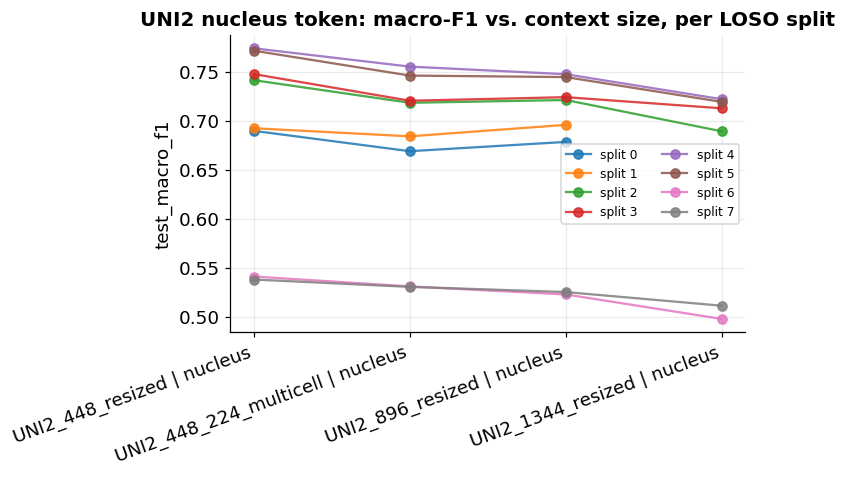

saved -> figures_classification_results/A_context_size_balacc_by_split.png


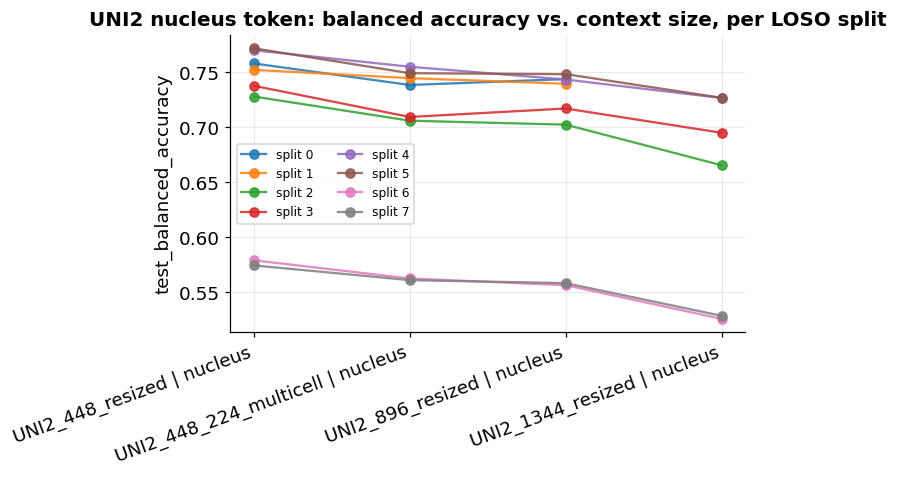

saved -> figures_classification_results/A_context_size_per_class.png


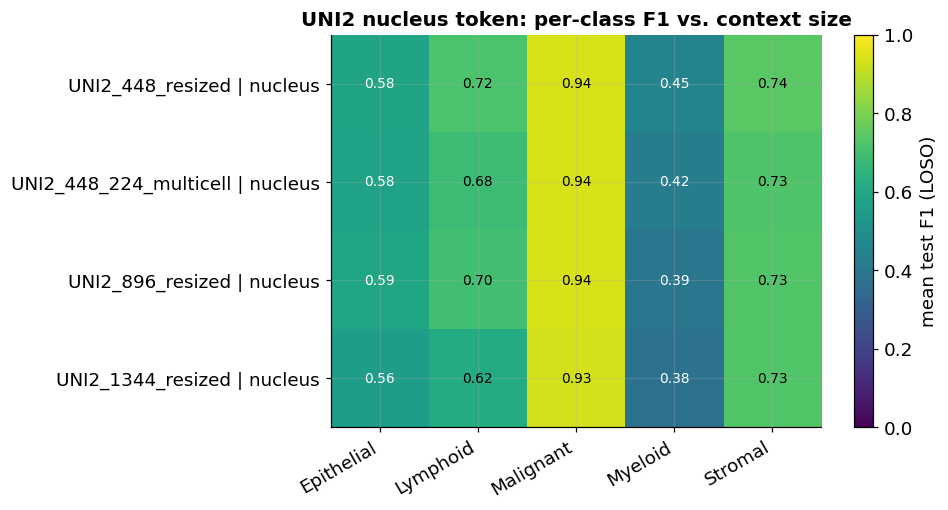

test_accuracy         test_balanced_accuracy         test_macro_f1         test_weighted_f1        
                                          mean     std                   mean     std          mean     std             mean     std
condition                                                                                                                           
UNI2_448_resized | nucleus              0.8006  0.0286                 0.7090  0.0830        0.6870  0.0961           0.7943  0.0347
UNI2_448_224_multicell | nucleus        0.7879  0.0216                 0.6909  0.0816        0.6694  0.0900           0.7805  0.0276
UNI2_896_resized | nucleus              0.7894  0.0250                 0.6888  0.0826        0.6700  0.0928           0.7814  0.0312
UNI2_1344_resized | nucleus             0.7726  0.0215                 0.6447  0.0939        0.6421  0.1071           0.7619  0.0324

In [6]:
context_conditions = [("UNI2", CENTRAL_EMBEDDING_TYPE["UNI2"])]
context_conditions += [(m, "nucleus") for m in CONTEXT_SIZE_FAMILY if m != "UNI2"]
if (RESULTS_ROOT / "UNI2_448_224_multicell").exists():
    context_conditions.append(("UNI2_448_224_multicell", "nucleus"))

context_order_key = {**{f"{m} | {e}": CONTEXT_SIZE_FAMILY.get(m, 449) for m, e in context_conditions}}
found_a, missing_a = existing_conditions(loso_df, context_conditions)
condition_order_a = sorted([f"{m} | {e}" for m, e in found_a], key=lambda c: context_order_key[c])

context_df = loso_df[loso_df.apply(lambda r: (r["model_name"], r["embeddings"]) in found_a, axis=1)].copy()

if condition_order_a:
    plot_metric_vs_condition_by_split(
        context_df, "test_macro_f1", condition_order_a,
        "UNI2 nucleus token: macro-F1 vs. context size, per LOSO split", "A_context_size_macrof1_by_split")
    plot_metric_vs_condition_by_split(
        context_df, "test_balanced_accuracy", condition_order_a,
        "UNI2 nucleus token: balanced accuracy vs. context size, per LOSO split", "A_context_size_balacc_by_split")
    plot_per_class_heatmap(
        per_class_df, condition_order_a, CLASS_ORDER,
        "UNI2 nucleus token: per-class F1 vs. context size", "A_context_size_per_class")

    summary_a = context_df.groupby("condition")[METRICS].agg(["mean", "std"])
    display(summary_a.reindex(condition_order_a).round(4))
else:
    print("none of the context-size conditions are on disk yet")

## B. CLS vs. central

For each of `{UNI2, UNI2_100_resized, UNI2_448_resized, HOptimus1,
virchow_v2}`: per-split macro-F1 for CLS vs. its central read-out, plus a
per-class F1 heatmap, plus explicit central-minus-CLS drop tables (per class,
and per split) so "which cell types / splits lose" is a number, not just a
color.

[not found on disk yet -- skipping] [('UNI2', 'bottom_left_bottom_right_top_left_top_right')]
saved -> figures_classification_results/B_cls_vs_central_macrof1_by_split.png


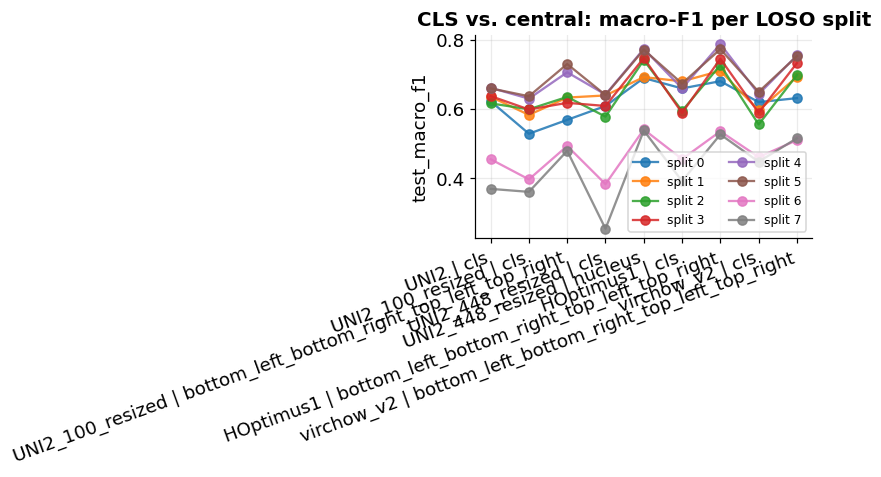

saved -> figures_classification_results/B_cls_vs_central_per_class.png


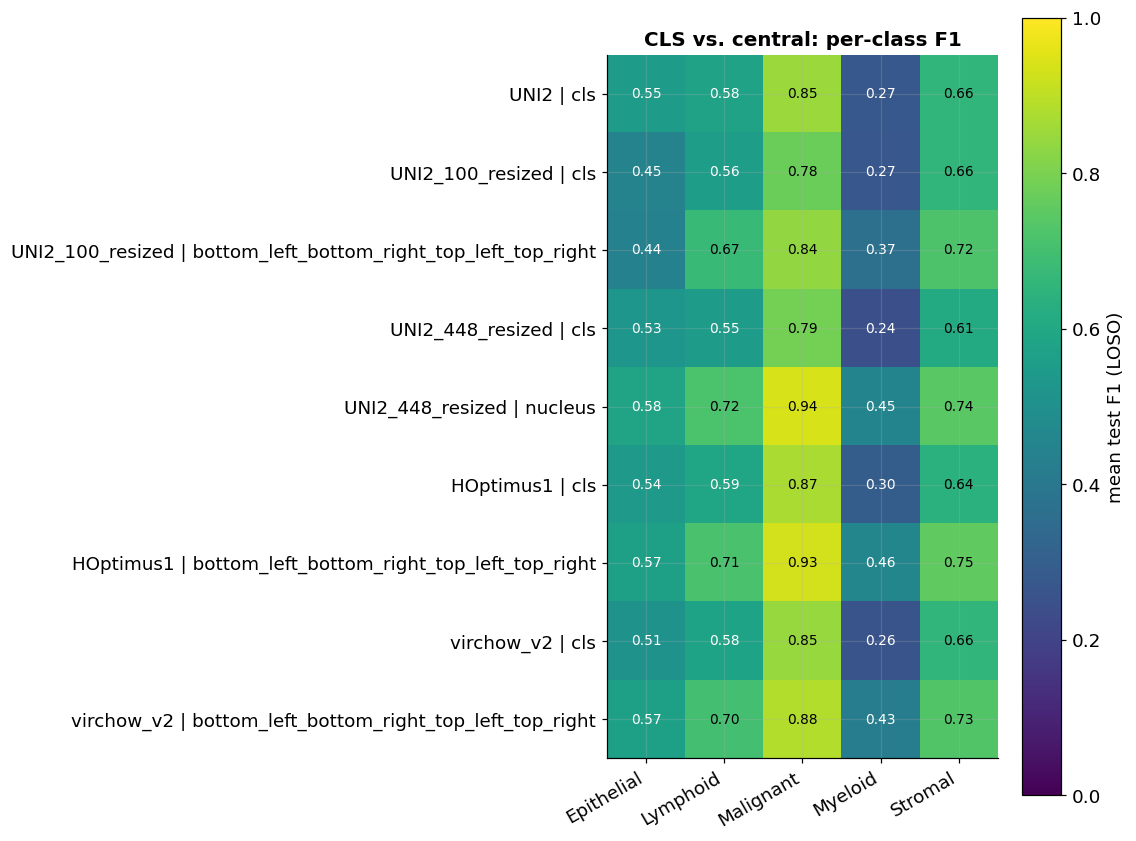

In [7]:
cls_central_models = ["UNI2", "UNI2_100_resized", "UNI2_448_resized", "HOptimus1", "virchow_v2"]

pairs = []
for m in cls_central_models:
    central_emb = CENTRAL_EMBEDDING_TYPE.get(m)
    if central_emb is None:
        print(f"[skip] no CENTRAL_EMBEDDING_TYPE entry for {m!r}")
        continue
    pairs.append((m, "cls", central_emb))

b_conditions = [c for m, cls_e, central_e in pairs for c in ((m, cls_e), (m, central_e))]
found_b, missing_b = existing_conditions(loso_df, b_conditions)
condition_order_b = [f"{m} | {e}" for m, e in b_conditions if (m, e) in found_b]

b_df = loso_df[loso_df.apply(lambda r: (r["model_name"], r["embeddings"]) in found_b, axis=1)].copy()

if condition_order_b:
    plot_metric_vs_condition_by_split(
        b_df, "test_macro_f1", condition_order_b,
        "CLS vs. central: macro-F1 per LOSO split", "B_cls_vs_central_macrof1_by_split")
    plot_per_class_heatmap(
        per_class_df, condition_order_b, CLASS_ORDER,
        "CLS vs. central: per-class F1", "B_cls_vs_central_per_class")
else:
    print("none of the CLS/central conditions are on disk yet")

In [8]:
def cls_vs_central_class_drop(per_class_df, model, cls_emb, central_emb, class_order):
    """Mean test per-class F1 for cls vs. central, and their difference, one row per class."""
    d = per_class_df[(per_class_df["model_name"] == model) & (~per_class_df["is_same_wsi"])
                      & (per_class_df["eval_set"] == "test")]
    cls_f1 = d[d["embeddings"] == cls_emb].groupby("class_name")["f1"].mean()
    central_f1 = d[d["embeddings"] == central_emb].groupby("class_name")["f1"].mean()
    out = pd.DataFrame({"cls": cls_f1, "central": central_f1}).reindex(class_order)
    out["central_minus_cls"] = out["central"] - out["cls"]
    return out


def cls_vs_central_split_drop(loso_df, model, cls_emb, central_emb, metric=PRIMARY_METRIC):
    """Same idea, per LOSO split_idx instead of per class."""
    d = loso_df[loso_df["model_name"] == model]
    cls_s = d[d["embeddings"] == cls_emb].set_index("split_idx")[metric]
    central_s = d[d["embeddings"] == central_emb].set_index("split_idx")[metric]
    out = pd.DataFrame({"cls": cls_s, "central": central_s}).sort_index()
    out["central_minus_cls"] = out["central"] - out["cls"]
    return out


for m, cls_e, central_e in pairs:
    if (m, cls_e) not in found_b or (m, central_e) not in found_b:
        continue
    print(f"\n=== {m}: per-class F1, central - cls ===")
    display(cls_vs_central_class_drop(per_class_df, m, cls_e, central_e, CLASS_ORDER).round(4))
    print(f"=== {m}: {PRIMARY_METRIC}, central - cls, per split ===")
    display(cls_vs_central_split_drop(loso_df, m, cls_e, central_e).round(4))


=== UNI2_100_resized: per-class F1, central - cls ===


,cls,central,central_minus_cls
class_name,,,
Epithelial,0.4454,0.4399,-0.0055
Lymphoid,0.5572,0.6737,0.1165
Malignant,0.7773,0.8396,0.0623
Myeloid,0.2732,0.3679,0.0948
Stromal,0.6567,0.7192,0.0626


=== UNI2_100_resized: test_macro_f1, central - cls, per split ===


,cls,central,central_minus_cls
split_idx,,,
0.0,0.5289,0.5689,0.0400
1.0,0.5832,0.6333,0.0501
2.0,0.5994,0.6351,0.0357
3.0,0.5988,0.6181,0.0192
4.0,0.6301,0.7062,0.0761
5.0,0.6370,0.7300,0.0930
6.0,0.3971,0.4935,0.0964
7.0,0.3611,0.4795,0.1185



=== UNI2_448_resized: per-class F1, central - cls ===


...

,cls,central,central_minus_cls
split_idx,,,
0.0,0.6596,0.6806,0.0210
1.0,0.6801,0.7103,0.0302
2.0,0.5948,0.7271,0.1323
3.0,0.5889,0.7453,0.1564
4.0,0.6597,0.7879,0.1282
5.0,0.6737,0.7731,0.0993
6.0,0.4556,0.5359,0.0802
7.0,0.3921,0.5268,0.1348



=== virchow_v2: per-class F1, central - cls ===


,cls,central,central_minus_cls
class_name,,,
Epithelial,0.5094,0.5675,0.0581
Lymphoid,0.5808,0.7019,0.1210
Malignant,0.8474,0.8832,0.0358
Myeloid,0.2581,0.4253,0.1672
Stromal,0.6568,0.7282,0.0714


=== virchow_v2: test_macro_f1, central - cls, per split ===


,cls,central,central_minus_cls
split_idx,,,
0.0,0.6201,0.6316,0.0115
1.0,0.5967,0.6931,0.0964
2.0,0.5556,0.6985,0.1428
3.0,0.5893,0.7328,0.1436
4.0,0.6432,0.7547,0.1116
5.0,0.6497,0.7528,0.1030
6.0,0.4614,0.5102,0.0488
7.0,0.4480,0.5159,0.0678


## C. Cell-type availability vs. performance

Train-set cell counts for a class (that split) vs. that class's test F1
(that split), for `{HOptimus1, UNI2, virchow_v2}` central tokens. Both raw
count and within-split proportion are shown -- raw count conflates "which WSIs
ended up in train" with genuine class rarity, proportion controls for that.

[not found on disk yet -- skipping] [('UNI2', 'bottom_left_bottom_right_top_left_top_right')]
saved -> figures_classification_results/C_availability_vs_f1.png


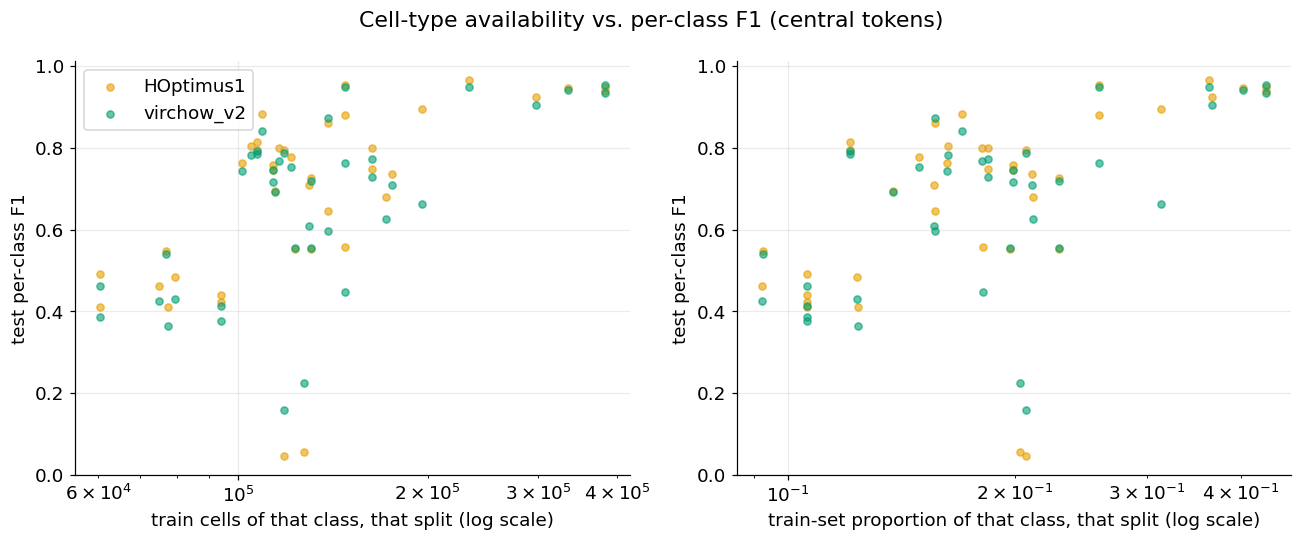

Spearman rho(availability, test F1), per model:
  HOptimus1: n_cells rho=0.613 (p=2.63e-05), proportion rho=0.582 (p=8.05e-05), n=40
  virchow_v2: n_cells rho=0.537 (p=0.000358), proportion rho=0.512 (p=0.000729), n=40

Per-class mean availability vs. mean F1 (averaged over splits):


,n_cells,proportion,f1
class_name,,,
Epithelial,128474.5,0.1798,0.5684
Lymphoid,118892.0,0.1706,0.7081
Malignant,265070.5,0.3531,0.9077
Myeloid,77189.0,0.1070,0.4421
Stromal,138457.5,0.1894,0.7414


In [9]:
avail_models = [(m, CENTRAL_EMBEDDING_TYPE[m]) for m in ["HOptimus1", "UNI2", "virchow_v2"]]
found_c, missing_c = existing_conditions(loso_df, avail_models)

avail_counts = counts_df[
    (counts_df["set"] == "train")
    & counts_df.apply(lambda r: (r["model_name"], r["embeddings"]) in found_c, axis=1)
].copy()
avail_f1 = per_class_df[
    (per_class_df["eval_set"] == "test") & (~per_class_df["is_same_wsi"])
    & per_class_df.apply(lambda r: (r["model_name"], r["embeddings"]) in found_c, axis=1)
].copy()

merge_keys = ["model_name", "embeddings", "split_idx", "class_name"]
avail_merged = avail_f1.merge(avail_counts[merge_keys + ["n_cells", "proportion"]], on=merge_keys, how="left")

if not avail_merged.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, xcol, xlabel in zip(axes, ["n_cells", "proportion"],
                                 ["train cells of that class, that split (log scale)",
                                  "train-set proportion of that class, that split (log scale)"]):
        for i, model in enumerate(["HOptimus1", "UNI2", "virchow_v2"]):
            d = avail_merged[avail_merged["model_name"] == model]
            if d.empty:
                continue
            ax.scatter(d[xcol], d["f1"], alpha=0.6, s=22, color=OKABE_ITO[i], label=model)
        ax.set_xscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("test per-class F1")
    axes[0].legend()
    fig.suptitle("Cell-type availability vs. per-class F1 (central tokens)")
    fig.tight_layout()
    savefig(fig, "C_availability_vs_f1")
    plt.show()

    print("Spearman rho(availability, test F1), per model:")
    for model in ["HOptimus1", "UNI2", "virchow_v2"]:
        d = avail_merged[(avail_merged["model_name"] == model) & avail_merged["n_cells"].notna()]
        if len(d) < 3:
            continue
        rho_n, p_n = stats.spearmanr(d["n_cells"], d["f1"])
        rho_p, p_p = stats.spearmanr(d["proportion"], d["f1"])
        print(f"  {model}: n_cells rho={rho_n:.3f} (p={p_n:.3g}), proportion rho={rho_p:.3f} (p={p_p:.3g}), n={len(d)}")

    print("\nPer-class mean availability vs. mean F1 (averaged over splits):")
    display(avail_merged.groupby("class_name")[["n_cells", "proportion", "f1"]].mean().reindex(CLASS_ORDER).round(4))
else:
    print("none of the availability conditions are on disk yet")

## D. Scaling law

Model parameter count and embedding dimension vs. mean macro-F1 (central
tokens, LOSO mean ± std across splits). Only three models -- not enough
points for a real trend fit, shown as a reference scatter only.

[skip] no central-token LOSO results for UNI2


,model,display,params_millions,embedding_dim,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_accuracy_std,test_balanced_accuracy_std,test_macro_f1_std,test_weighted_f1_std
0,HOptimus1,H-Optimus-1,1100,1536,0.7970,0.7079,0.6859,0.7939,0.0380,0.0918,0.1012,0.0412
1,virchow_v2,Virchow2,632,1280,0.7477,0.6863,0.6612,0.7575,0.0965,0.0863,0.0996,0.0755


saved -> figures_classification_results/D_scaling_law.png


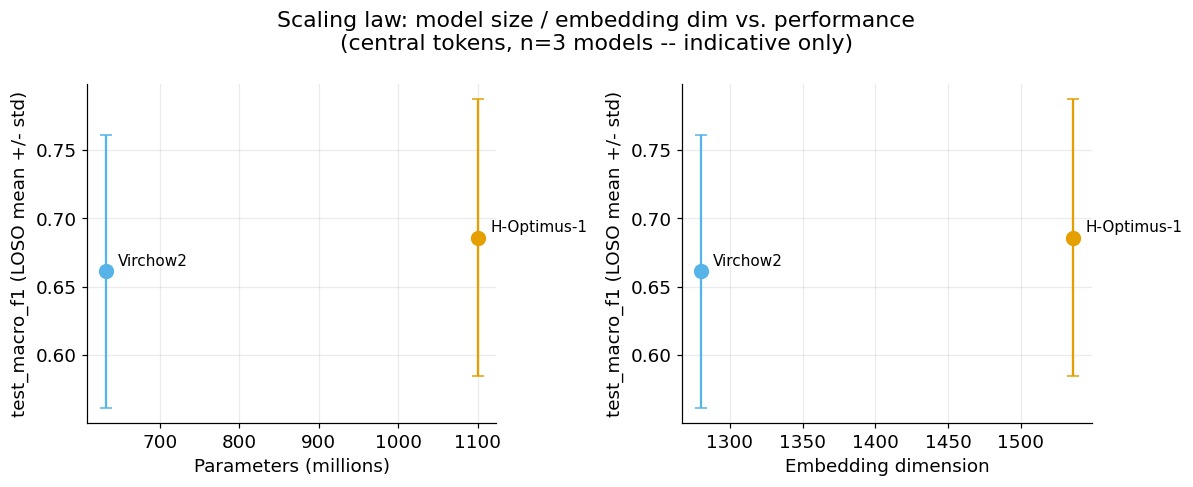

In [10]:
scaling_rows = []
for model in ["HOptimus1", "UNI2", "virchow_v2"]:
    central_emb = CENTRAL_EMBEDDING_TYPE[model]
    d = loso_df[(loso_df["model_name"] == model) & (loso_df["embeddings"] == central_emb)]
    if d.empty:
        print(f"[skip] no central-token LOSO results for {model}")
        continue
    info = MODEL_INFO[model]
    scaling_rows.append({
        "model": model, "display": info["display"],
        "params_millions": info["params_millions"], "embedding_dim": info["embedding_dim"],
        **{m: d[m].mean() for m in METRICS},
        **{f"{m}_std": d[m].std() for m in METRICS},
    })
scaling_df = pd.DataFrame(scaling_rows)
display(scaling_df.round(4))

if not scaling_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, xcol, xlabel in zip(axes, ["params_millions", "embedding_dim"],
                                 ["Parameters (millions)", "Embedding dimension"]):
        for i, row in scaling_df.iterrows():
            ax.errorbar(row[xcol], row[PRIMARY_METRIC], yerr=row[f"{PRIMARY_METRIC}_std"],
                         marker="o", markersize=9, color=OKABE_ITO[i], capsize=4)
            ax.annotate(row["display"], (row[xcol], row[PRIMARY_METRIC]),
                        textcoords="offset points", xytext=(8, 4), fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f"{PRIMARY_METRIC} (LOSO mean +/- std)")
    fig.suptitle("Scaling law: model size / embedding dim vs. performance\n(central tokens, n=3 models -- indicative only)")
    fig.tight_layout()
    savefig(fig, "D_scaling_law")
    plt.show()